# Shared Utilities (USE FOR ALL BASELINES)

In [ ]:
!pip install --upgrade transformers datasets


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [ ]:
import pandas as pd

df = pd.read_excel("xxxx")#upload your dataset here with correct column name


# Mandatory Cleaning

In [ ]:
# Keep only required columns
df = df[['commit_id', 'p_text', 'so_id', 's_text', 'label']].copy()

# Drop invalid rows
df.dropna(subset=['p_text', 's_text', 'label'], inplace=True)

# Ensure binary labels
df['label'] = df['label'].astype(int)
df = df[df['label'].isin([0, 1])]

# Reset index
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df['label'].value_counts())


In [ ]:
def clean_text(x):
    x = x.lower()
    x = x.replace('\n', ' ')
    x = x.replace('\t', ' ')
    return x.strip()

df['p_text'] = df['p_text'].apply(clean_text)
df['s_text'] = df['s_text'].apply(clean_text)


In [ ]:
def get_pair_text(df):
    X = (df['p_text'] + " [SEP] " + df['s_text']).values
    y = df['label'].values
    return X, y


In [ ]:
def evaluate_binary_classifier(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    P, R, F = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        p, r, f, _ = precision_recall_fscore_support(
            y[test_idx], y_pred, average='binary'
        )
        P.append(p); R.append(r); F.append(f)

    return np.mean(P), np.mean(R), np.mean(F)


# GMR Baseline (Similarity-Threshold Model)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.linear_model import LogisticRegression

In [ ]:


class GMRBaseline:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
        self.clf = LogisticRegression(max_iter=1000)

    def fit(self, X, y):
        # For each pair, join p_text + " [SEP] " + s_text
        X_vec = self.vectorizer.fit_transform(X)
        self.clf.fit(X_vec, y)

    def predict(self, X):
        X_vec = self.vectorizer.transform(X)
        return self.clf.predict(X_vec)


# FITSEA Baseline (Feature-based Supervised Model)

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
def jaccard_similarity(a, b):
    a, b = set(a.split()), set(b.split())
    return len(a & b) / max(1, len(a | b))


In [ ]:
class FITSEABaseline:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            stop_words='english',
            max_features=5000
        )
        self.clf = LogisticRegression(max_iter=1000)

    def fit(self, X, y):
        p_texts, s_texts = [], []
        for pair in X:
            p, s = pair.split("[SEP]")
            p_texts.append(p)
            s_texts.append(s)

        tfidf = self.vectorizer.fit_transform(p_texts + s_texts)
        n = len(X)
        p_vecs, s_vecs = tfidf[:n], tfidf[n:]

        cos = cosine_similarity(p_vecs, s_vecs).diagonal()
        jac = [jaccard_similarity(p_texts[i], s_texts[i]) for i in range(n)]

        feats = np.vstack([cos, jac]).T
        self.clf.fit(feats, y)

    def predict(self, X):
        p_texts, s_texts = [], []
        for pair in X:
            p, s = pair.split("[SEP]")
            p_texts.append(p)
            s_texts.append(s)

        tfidf = self.vectorizer.transform(p_texts + s_texts)
        n = len(X)
        p_vecs, s_vecs = tfidf[:n], tfidf[n:]

        cos = cosine_similarity(p_vecs, s_vecs).diagonal()
        jac = [jaccard_similarity(p_texts[i], s_texts[i]) for i in range(n)]

        feats = np.vstack([cos, jac]).T
        return self.clf.predict(feats)


# Common Utilities (required once)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def evaluate_with_confusion_matrix(model, X, y, n_splits=5, title="Model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    ps, rs, fs = [], [], []
    cm_total = np.zeros((2, 2), dtype=int)

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        p, r, f, _ = precision_recall_fscore_support(
            y_test, y_pred, average="binary"
        )
        ps.append(p); rs.append(r); fs.append(f)

        cm = confusion_matrix(y_test, y_pred)
        cm_total += cm

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_total, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(f"{title} — Confusion Matrix")
    plt.show()

    return np.mean(ps), np.mean(rs), np.mean(fs), cm_total




#Run Each Baseline

## SVM Baseline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

class SVMBaseline:
    def __init__(self):
        self.model = Pipeline([
            ('tfidf', TfidfVectorizer(
                stop_words='english',
                max_features=10000
            )),
            ('svm', LinearSVC())
        ])

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)



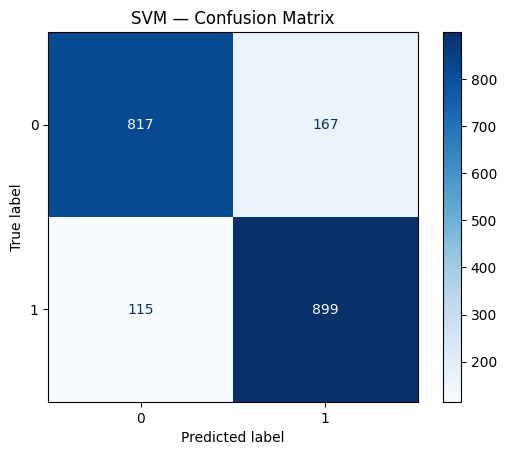

SVM → Precision=0.8438, Recall=0.8866, F1=0.8646
[[817 167]
 [115 899]]


In [ ]:
X, y = get_pair_text(df)

svm = SVMBaseline()
p, r, f, cm = evaluate_with_confusion_matrix(svm, X, y, title="SVM")
print(f"SVM → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)



Repeat for:

## GMR Baseline

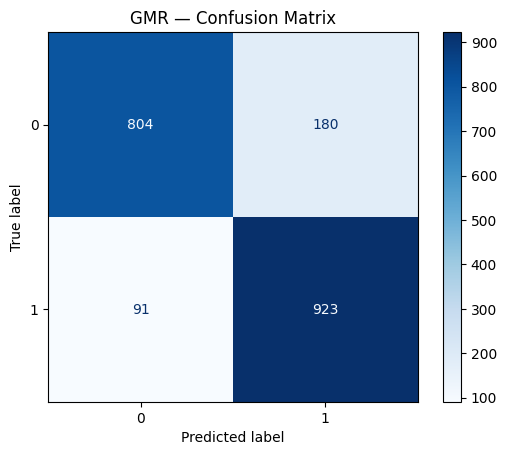

GMR → Precision=0.8371, Recall=0.9103, F1=0.8720
[[804 180]
 [ 91 923]]


In [ ]:
gmr = GMRBaseline()
p, r, f, cm = evaluate_with_confusion_matrix(gmr, X, y, title="GMR")
print(f"GMR → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)



## FITSEA Baseline

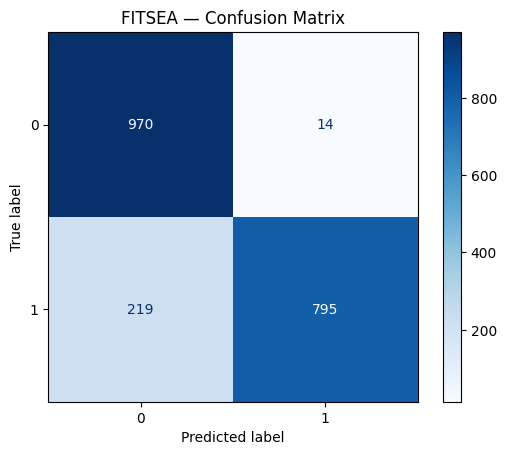

FITSEA → Precision=0.9827, Recall=0.7840, F1=0.8720
[[970  14]
 [219 795]]


In [ ]:
fitsea = FITSEABaseline()
p, r, f, cm = evaluate_with_confusion_matrix(fitsea, X, y, title="FITSEA")
print(f"FITSEA → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")
print(cm)
